# LSTM vs GRU vs Bidirectional LSTM — Time Series Prediction

We generate a reproducible synthetic noisy sine wave with `numpy` (fixed `np.random.seed`), frame it as a windowed sequence-prediction task (predict the next value given the last `WINDOW` values), and train/compare three recurrent architectures on it: a plain `LSTM`, a plain `GRU`, and a `Bidirectional(LSTM(...))`. This mirrors how a real univariate series (e.g. a stock price) would be framed, per `notes.md`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import mean_squared_error

np.random.seed(42)
tf.random.set_seed(42)

print('TF version:', tf.__version__)

I0000 00:00:1787472345.806696   27303 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787472345.807306   27303 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787472345.848580   27303 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787472346.724142   27303 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787472346.724401   27303 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TF version: 2.21.0


## Generate a synthetic noisy sine wave

A smooth periodic trend plus Gaussian noise, similar in character to many real sensor / financial time series (trend + noise).

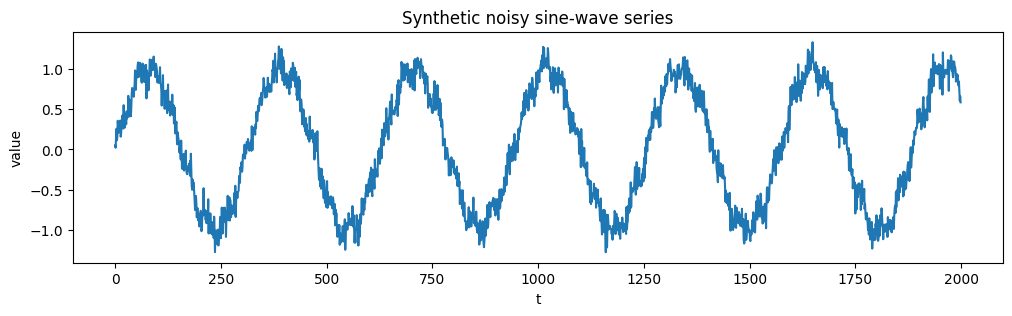

In [2]:
N_POINTS = 2000
t = np.arange(N_POINTS)
series = np.sin(0.02 * t) + 0.1 * np.sin(0.15 * t) + 0.1 * np.random.randn(N_POINTS)
series = series.astype('float32')

plt.figure(figsize=(12, 3))
plt.plot(series)
plt.title('Synthetic noisy sine-wave series')
plt.xlabel('t'); plt.ylabel('value')
plt.show()

## Windowed sequence-prediction framing

Each training example is a window of `WINDOW` consecutive values used to predict the very next value.

In [3]:
WINDOW = 30

def make_windows(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i + window])
        y.append(data[i + window])
    return np.array(X), np.array(y)

X_all, y_all = make_windows(series, WINDOW)
X_all = X_all[..., np.newaxis]  # (samples, timesteps, 1 feature)
print(X_all.shape, y_all.shape)

(1970, 30, 1) (1970,)


In [4]:
n = len(X_all)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train, y_train = X_all[:train_end], y_all[:train_end]
X_val, y_val = X_all[train_end:val_end], y_all[train_end:val_end]
X_test, y_test = X_all[val_end:], y_all[val_end:]

print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)

Train: (1379, 30, 1) Val: (295, 30, 1) Test: (296, 30, 1)


## Build and train three models

Each model has one recurrent layer (16 units) followed by a linear `Dense(1)` output, trained with Adam and MSE loss under identical settings so the comparison is fair.

In [5]:
def build_model(rnn_layer):
    model = keras.Sequential([
        layers.Input(shape=(WINDOW, 1)),
        rnn_layer,
        layers.Dense(1),
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

models = {
    'LSTM': build_model(layers.LSTM(16)),
    'GRU': build_model(layers.GRU(16)),
    'BiLSTM': build_model(layers.Bidirectional(layers.LSTM(16))),
}

histories = {}
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

for name, model in models.items():
    print(f'--- Training {name} ---')
    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=15, batch_size=32,
        callbacks=[early_stop], verbose=0)
    histories[name] = hist
    print(f'{name} epochs run: {len(hist.history["loss"])}')

E0000 00:00:1787472347.642063   27303 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1787472347.642611   27361 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1787472347.665782   27303 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


--- Training LSTM ---


LSTM epochs run: 15
--- Training GRU ---


GRU epochs run: 15
--- Training BiLSTM ---


BiLSTM epochs run: 15


## Training loss curves

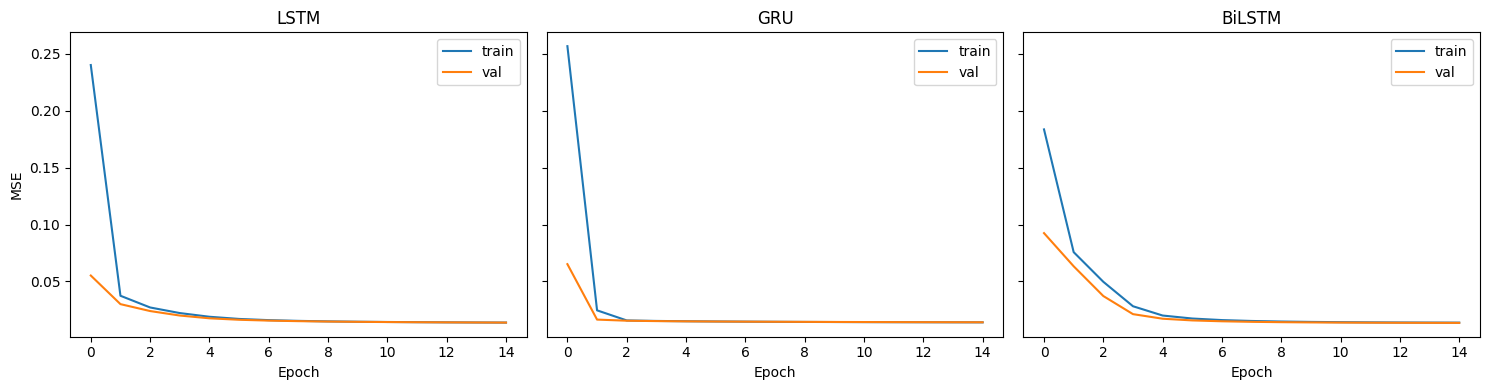

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for i, (name, hist) in enumerate(histories.items()):
    ax[i].plot(hist.history['loss'], label='train')
    ax[i].plot(hist.history['val_loss'], label='val')
    ax[i].set_title(name); ax[i].set_xlabel('Epoch'); ax[i].legend()
ax[0].set_ylabel('MSE')
plt.tight_layout()
plt.show()

## Evaluate on the test set: predicted vs. actual

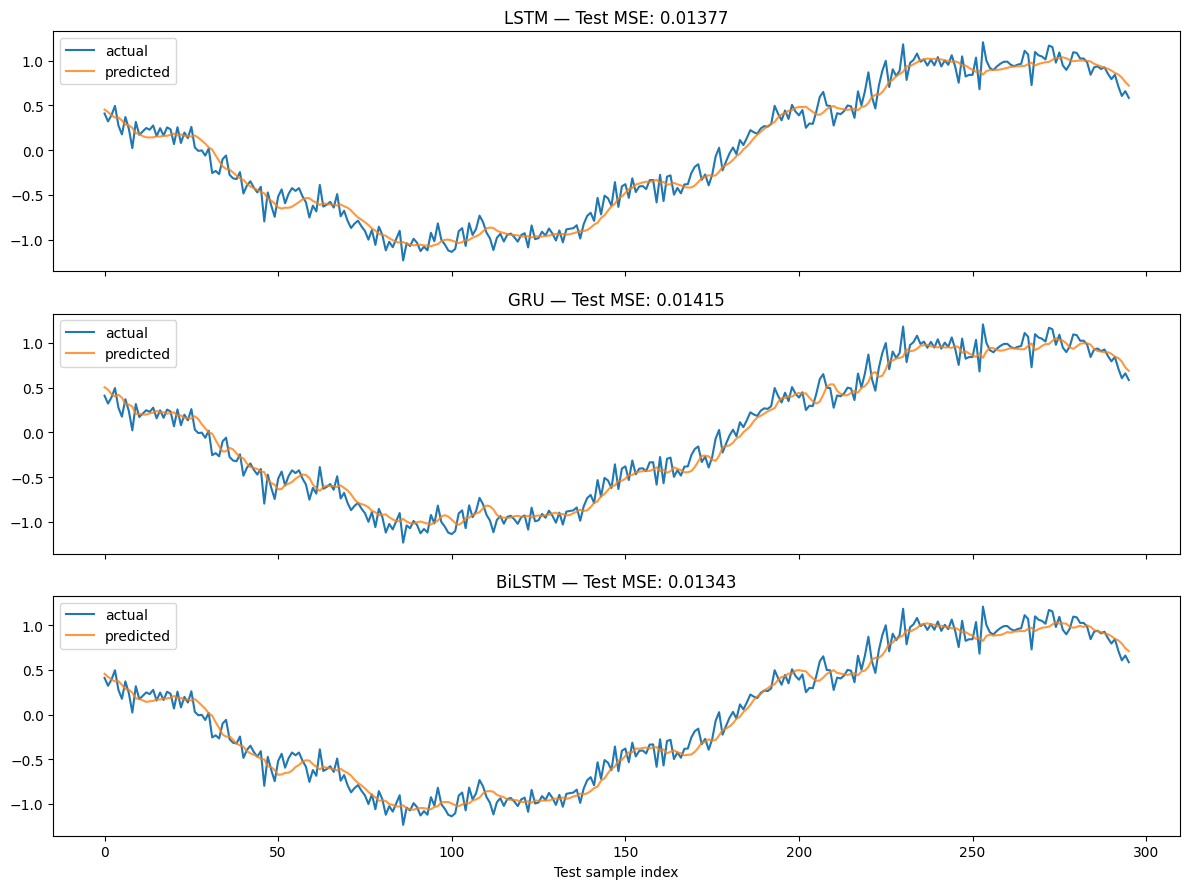

In [7]:
results = {}
fig, ax = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test, verbose=0).flatten()
    mse = mean_squared_error(y_test, y_pred)
    results[name] = mse
    ax[i].plot(y_test, label='actual')
    ax[i].plot(y_pred, label='predicted', alpha=0.8)
    ax[i].set_title(f'{name} — Test MSE: {mse:.5f}')
    ax[i].legend()
ax[-1].set_xlabel('Test sample index')
plt.tight_layout()
plt.show()

In [8]:
print('Test MSE comparison:')
for name, mse in results.items():
    print(f'  {name:8s}: {mse:.5f}')

Test MSE comparison:
  LSTM    : 0.01377
  GRU     : 0.01415
  BiLSTM  : 0.01343


## Summary

All three gated architectures track the underlying sine-wave trend on held-out data; differences in test MSE reflect the architectural tradeoffs discussed in `notes.md` — GRU's fewer parameters vs. LSTM's more expressive gating vs. BiLSTM's access to both directions of context (useful here since the whole window is known at prediction time).